In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [ ]:
df =pd.read_excel('C:/Users/Nischay/Downloads/linear_regression_dataset.xlsx')
print(df.shape)
df.head()

(250, 11)


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,target
0,-0.885348,-0.318384,-0.681882,-0.525339,-0.173139,-0.049100,-0.730028,0.268017,0.844092,0.086956,13.812971
1,0.035805,0.914707,-0.779525,0.765028,0.616923,-0.072274,-0.857656,0.717170,-0.900923,-0.332585,21.425618
2,-0.236609,0.480134,0.653774,0.476751,-0.574669,0.368244,0.770633,0.816649,0.071216,-0.325806,-9.472456
3,0.348254,0.887513,-0.530695,0.089664,0.440671,0.551195,-0.533984,-0.192555,0.525992,-0.941095,7.606811
4,0.208330,-0.780880,0.413807,0.672348,0.202937,-0.898062,-0.744548,-0.823112,-0.303068,-0.614794,0.307696


In [5]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      250 non-null    float64
 1   x1      250 non-null    float64
 2   x2      250 non-null    float64
 3   x3      250 non-null    float64
 4   x4      250 non-null    float64
 5   x5      250 non-null    float64
 6   x6      250 non-null    float64
 7   x7      250 non-null    float64
 8   x8      250 non-null    float64
 9   x9      250 non-null    float64
 10  target  250 non-null    float64
dtypes: float64(11)
memory usage: 21.6 KB


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,target
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.066993,0.019975,0.041093,-0.059924,0.037511,0.010189,-0.055190,0.059748,0.001512,-0.010271,4.119904
std,0.582216,0.578704,0.592574,0.600519,0.583696,0.563888,0.566449,0.548809,0.568715,0.582101,9.546344
min,-0.990045,-0.995725,-0.984495,-0.996218,-0.998647,-0.999469,-0.997808,-0.986700,-0.995511,-0.998175,-16.855749
25%,-0.375321,-0.442177,-0.462756,-0.612056,-0.467282,-0.395592,-0.548815,-0.366555,-0.484113,-0.502621,-3.354981
50%,0.063760,0.050484,0.093862,-0.027408,0.084419,-0.029009,-0.082588,0.074044,0.051957,-0.060621,4.071498
75%,0.600529,0.495501,0.552246,0.476257,0.575316,0.514831,0.381936,0.565957,0.492636,0.541512,11.489982
max,0.995952,0.990795,0.999734,0.992743,0.982925,0.990089,0.996948,0.993871,0.990693,0.999057,28.797352


In [9]:
X=df.drop(columns=['target']).values
Y=df['target'].values

X_b=np.c_[np.ones(X.shape[0]),X]
X_train, X_test, y_train, y_test = train_test_split(X_b,Y,test_size=0.2,random_state=42)


In [28]:
#normal eqn method
theta_normal=np.linalg.inv(X_train.T@X_train)@X_train.T@y_train
print(theta_normal)

[ 4.18160351 -1.78681503  1.94466359 -7.38220009  3.04819789  5.28985342
 -1.63400418 -6.99912346  1.07346327  1.1849256   9.84872135]


[ 4.18156265 -1.81533406  1.95826956 -7.28505889  2.99971305  5.3432063
 -1.69279908 -6.96029132  1.10142375  1.12805225  9.74707523]


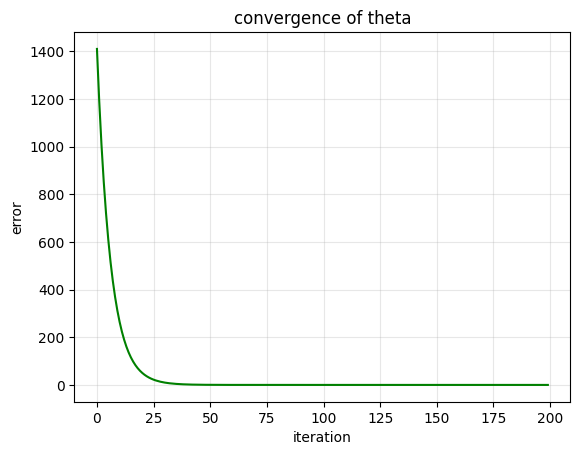

In [35]:
#gradient descent
learning_rate=0.1
m=len(X)
n_iterations=200

theta_gd=np.zeros(X_train.shape[1])
error_history=[]

for i in range(n_iterations):
    y_pred=X_train@theta_gd
    error=y_pred-y_train
    error_history.append(1/(2*m)*np.sum(error)**2)
    gradient=1/m*X_train.T@error
    theta_gd-=learning_rate*gradient

print(theta_gd)

plt.plot(error_history,color='green')
plt.xlabel('iteration')
plt.ylabel('error')
plt.title("convergence of theta")
plt.grid(alpha=0.3)
plt.show()



In [36]:
#accuracy check for both 
y_pred_normal=X_test@theta_normal
y_pred_gd=X_test@theta_gd

print("accuracy for gradient descent:")
print((y_test-y_pred_gd)**2)
print('\n')

print("accuracy for normal eqn")
print((y_test-y_pred_normal)**2)




accuracy for gradient descent:
[ 1.22143588  8.99464435  0.09733005  0.05273605  0.01784796  2.56312525
  3.45910703  1.25462283  1.04391357  0.23076857  0.26027866  0.02923361
  0.94465061  2.55302208  0.14589602  0.01821992  0.0658292   2.45848053
  0.29850335  0.21457195 10.04868234  0.57318749  0.33266846  0.07081004
  0.5557753   0.05421806  0.17139157  0.36098906  1.94692838  0.43799298
  0.20261211  0.035045    0.08082136  0.17847095  0.74113515  2.97333821
  0.10550614  0.01611758  0.59041901  0.13917957  0.04950943  2.1308817
  0.02033733  0.01089787  0.28643406  0.45527261  1.17172756  0.19856579
  0.24725169  0.70443479]


accuracy for normal eqn
[1.51218814e+00 1.01781775e+01 4.51670983e-02 1.06038578e-01
 2.67772173e-03 2.47726970e+00 3.98299583e+00 1.66963784e+00
 1.08393895e+00 1.57358263e-01 1.16391449e-01 5.74365351e-02
 5.60125568e-01 3.17464117e+00 1.29554559e-01 6.87141973e-04
 1.41863337e-01 2.34114160e+00 3.25620729e-01 2.39043147e-01
 1.03316294e+01 3.91249649e-0

In [ ]:
#REPORT 
#I implemented the linear regression both using gradient descent and normal equtation
#I plotted the graph to show the convergece of theta with the number of iterations using this graph I concluded the ideal value of n_iterations to be 200 after varying it from 100 to 10000
# at last i checked the error in the prediction of the test data  